# <center> Emotions Classification in Images <center/>
<center> <b>DLBDSAIS02<b/> - Project : Artificial Intelligence <center/>
<center> IU International University of Applied Sciences <center/>

## Objective :
In this project, our goal is to develop a model capable of classifying facial expressions into one of **four emotion categories**: Anger, Joy, Neutral, and Surprise. Emotion recognition from facial images is a fundamental task in affective computing with applications in human-computer interaction, mental health monitoring, and customer experience analysis.

In this notebook, we walk through the complete pipeline — from exploratory data analysis to model training and evaluation — to select the best-performing architecture for this task.


## Table of Contents
1. [Exploratory Data Analysis](#1.-Exploratory-Data-Analysis)
    * 1.1. Class Distribution
    * 1.2. Sample Images
    * 1.3. Image Properties
    * 1.4. Pixel Intensity Analysis
    * 1.5. Channel Statistics
2. [Data Preparation](#2.-Data-Preparation)
    * 2.1. Transforms & Augmentation
    * 2.2. Datasets & DataLoaders
    * 2.3. Class Weight Computation
    * 2.4. Augmentation Preview
3. [Model Development](#3.-Model-Development)
    * 3.1. Baseline CNN
    * 3.2. ResNet-18 (Transfer Learning)
    * 3.3. Training Infrastructure
    * 3.4. Training
4. [Evaluation & Analysis](#4.-Evaluation-&-Analysis)
    * 4.1. Training Curves
    * 4.2. Test Set Evaluation
    * 4.3. Confusion Matrices
    * 4.4. Model Comparison
    * 4.5. Misclassified Samples
5. [Summary](#5.-Summary)

## About the Dataset
The dataset used in this project is the **MMA Facial Expression** dataset, available on [Kaggle](https://www.kaggle.com/datasets/mahmoudima/mma-facial-expression). It contains over **127,000** facial images categorized into four universal emotion classes: **Anger**, **Joy**, **Neutral**, and **Surprise**.

All images are **48×48 pixels** in **RGB** color (JPEG format). The dataset comes pre-split into **train**, **test**, and **validation** folders, each containing one subfolder per emotion class.

**Key challenge:** The dataset exhibits **significant class imbalance** — classes like *happy* and *neutral* contain roughly 9× more samples than *disgust*. This must be addressed during training.

The data used in this project is massive. To download the data directly from KaggleHub use the following script :

In [ ]:
### Uncomment in case you want to download the dataset
# Import the library
# import kagglehub

# Download latest version
# path = kagglehub.dataset_download("mahmoudima/mma-facial-expression")

# print("Path to dataset files:", path)

We begin by importing all necessary libraries and setting up global configuration variables.

In [1]:
# Import the required libraries
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from collections import Counter
import torch.optim as optim
from pathlib import Path
import seaborn as sns
import torch.nn as nn
from PIL import Image
import pandas as pd
import numpy as np
import warnings
import random
import torch
import os

# Ignore the irrelevant warnings
warnings.filterwarnings('ignore')

In [2]:
# Paths (relative to notebooks/ directory)
DATA_DIR = Path('../data')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR  = DATA_DIR / 'test'
MODEL_DIR = Path('../models')
MODEL_DIR.mkdir(exist_ok=True)

# Visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Class names (alphabetical — matches folder order from ImageFolder)
CLASS_NAMES = ['angry', 'happy', 'neutral', 'surprise']
NUM_CLASSES = len(CLASS_NAMES)

# Image & training hyperparameters
IMG_SIZE            = 48       # Native resolution of the dataset
RESNET_IMG_SIZE     = 224      # Input size expected by pretrained ResNet
BATCH_SIZE          = 64
LEARNING_RATE       = 1e-3
NUM_EPOCHS          = 20
PATIENCE            = 5

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# Device selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device : {DEVICE}')

### Todo : Keep or remove
if DEVICE.type == 'cuda':
    print(f'GPU Name     : {torch.cuda.get_device_name(0)}')
    print(f'GPU Memory   : {torch.cuda.get_device_properties(0).total_mem / 1e9:.1f} GB')

Using device : cpu


## 1. Exploratory Data Analysis
Before building any model, we must thoroughly understand the data we're working with. This section examines class distributions, sample images, image properties, and pixel-level statistics.

### 1.1 Class Distribution
Let's start by analysing the distribution of images in each emotion class across all three splits.

In [3]:
# Define a helping function
def count_images(directory) -> dict:
    """Count images per class in a directory with class subfolders."""
    # Empty dict
    result = {}

    # Loop on the directory
    for cls_dir in sorted(directory.iterdir()):
        if cls_dir.is_dir() and cls_dir.name in CLASS_NAMES:
            result[cls_dir.name] = len(list(cls_dir.glob('*')))

    # Return dict
    return result

In [4]:
# Count images for each split
train_counts = count_images(TRAIN_DIR)
valid_counts = count_images(VALID_DIR)
test_counts  = count_images(TEST_DIR)

# Build summary DataFrame
df_counts = pd.DataFrame({
    'Train': train_counts,
    'Validation': valid_counts,
    'Test': test_counts
})
df_counts['Total'] = df_counts.sum(axis=1)
df_counts.loc['TOTAL'] = df_counts.sum()
df_counts = df_counts.astype(int)

# display DataFrame
df_counts

,Train,Validation,Test,Total
angry,6566,1017,1041,8624
happy,28592,5475,5459,39526
neutral,29384,5839,5858,41081
surprise,8113,1474,1475,11062
TOTAL,72655,13805,13833,100293


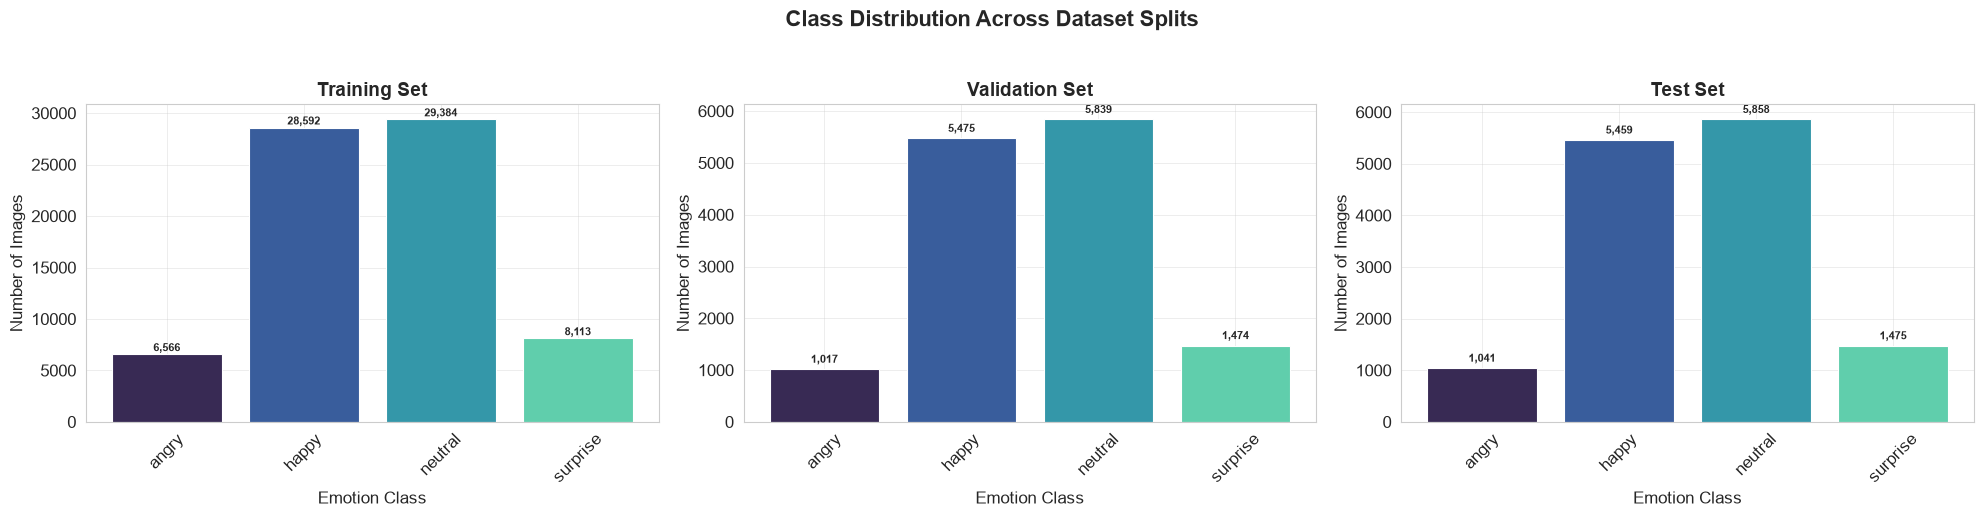

In [5]:
# Initiate a figure
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
palette = sns.color_palette('mako', NUM_CLASSES)

# Define splits
splits = {
    'Training Set': train_counts,
    'Validation Set': valid_counts,
    'Test Set': test_counts
}

# Loop on the splits
for ax, (title, counts) in zip(axes, splits.items()):
    
    # Create barchart
    bars = ax.bar(counts.keys(), counts.values(), color=palette, edgecolor='white', linewidth=0.8)
    
    # Set plot properties
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Emotion Class')
    ax.set_ylabel('Number of Images')
    ax.tick_params(axis='x', rotation=45)

    # Annotate bars
    for bar, count in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width() / 2., bar.get_height() + 80,
                f'{count:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Add subtitle, adjust view, and display it
plt.suptitle('Class Distribution Across Dataset Splits', fontsize=16, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [6]:
# Imbalance summary
max_cls = max(train_counts, key=train_counts.get)
min_cls = min(train_counts, key=train_counts.get)
ratio   = train_counts[max_cls] / train_counts[min_cls]

print(f'\nImbalance Analysis (Training Set):')
print(f'  Largest  class : {max_cls:>8s} → {train_counts[max_cls]:>6,} images')
print(f'  Smallest class : {min_cls:>8s} → {train_counts[min_cls]:>6,} images')
print(f'  Imbalance ratio: {ratio:.1f}x')
print(f'\n  ⚠ This severe imbalance will be addressed via weighted loss in Section 4.')


Imbalance Analysis (Training Set):
  Largest  class :  neutral → 29,384 images
  Smallest class :    angry →  6,566 images
  Imbalance ratio: 4.5x

  ⚠ This severe imbalance will be addressed via weighted loss in Section 4.


### 1.2 Sample Images
Let's visualize random sample images from each emotion class to build visual intuition about the data.

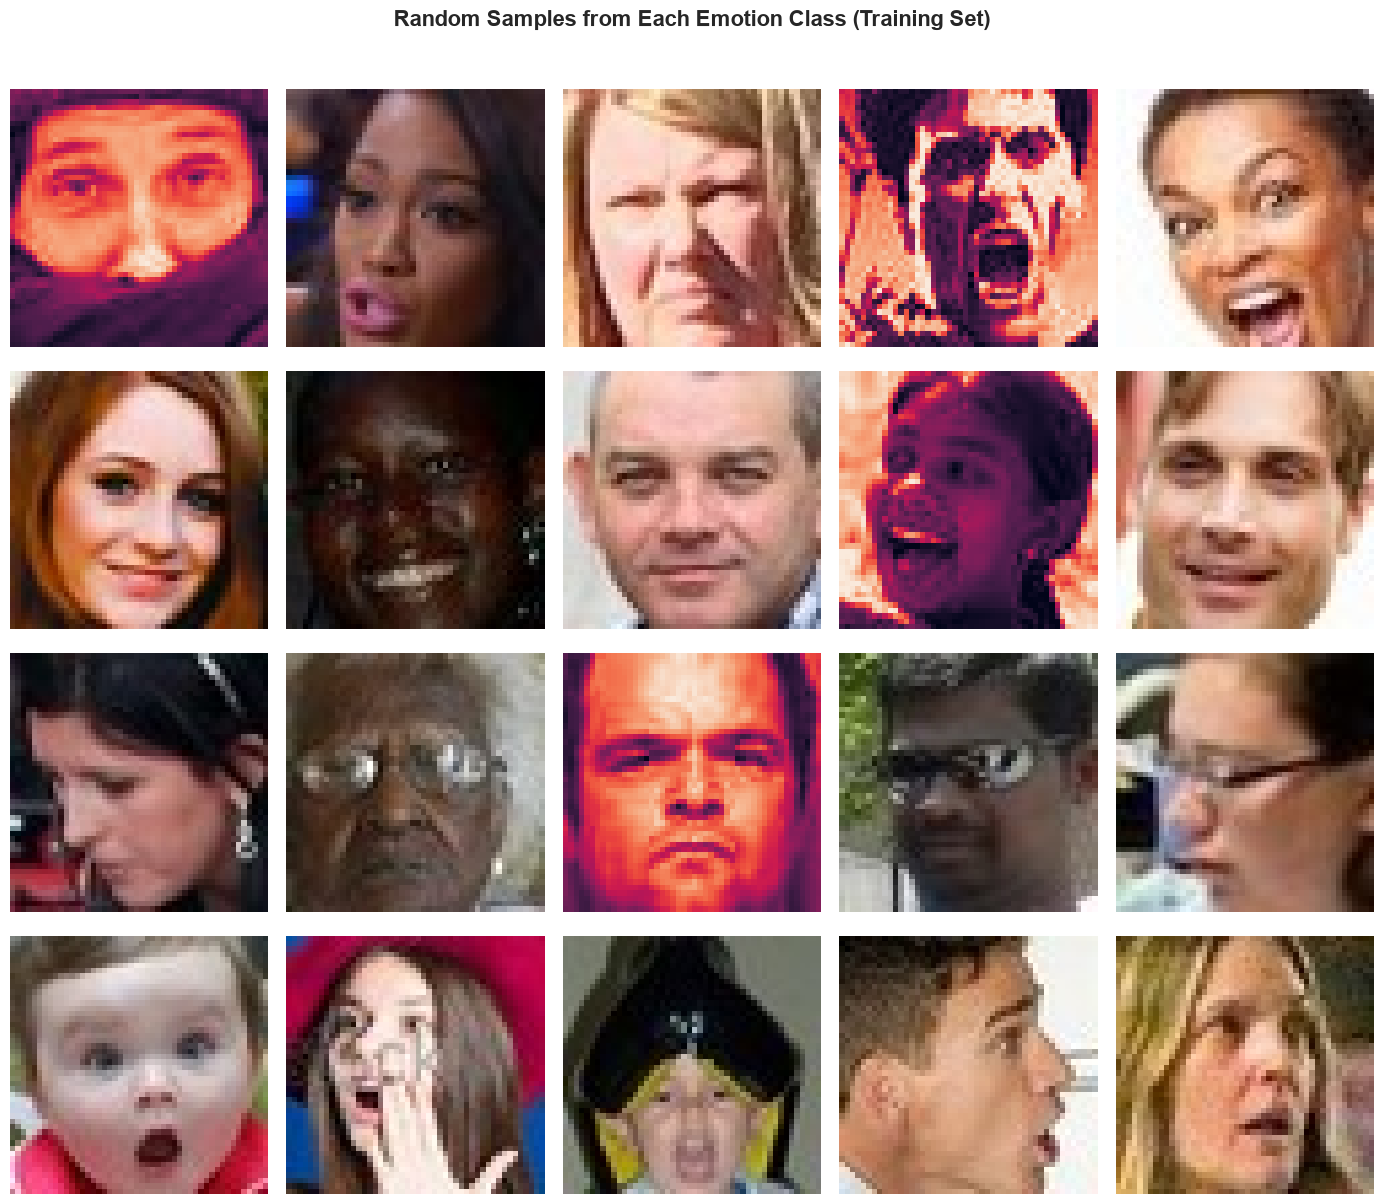

In [7]:
# Display a grid of sample images: 7 rows (classes) × 5 columns (samples)
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(14, 3 * NUM_CLASSES))

for i, cls_name in enumerate(CLASS_NAMES):
    cls_dir = TRAIN_DIR / cls_name
    sample_files = random.sample(list(cls_dir.iterdir()), 5)

    for j, img_path in enumerate(sample_files):
        img = Image.open(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis('off')

        if j == 0:
            axes[i, j].set_ylabel(cls_name.upper(), fontsize=12, fontweight='bold', rotation=0, labelpad=60, va='center')
            axes[i, j].yaxis.set_visible(True)
            axes[i, j].tick_params(left=False)

# Add title
plt.suptitle('Random Samples from Each Emotion Class (Training Set)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 1.3 Image Properties
We verify that all images are consistent in size and color mode.

In [8]:
# Sample images from all classes to check properties
sample_info = {'size': [], 'mode': [], 'class': []}

for cls_dir in sorted(TRAIN_DIR.iterdir()):
    if cls_dir.is_dir() and cls_dir.name in CLASS_NAMES:
        for img_path in list(cls_dir.iterdir())[:10]:
            img = Image.open(img_path)
            sample_info['size'].append(img.size)
            sample_info['mode'].append(img.mode)
            sample_info['class'].append(cls_dir.name)

# Construct the dataframe
df_props = pd.DataFrame(sample_info)

print('Image Properties Summary')
print('=' * 40)
print(f"  Unique sizes : {df_props['size'].unique()}")
print(f"  Unique modes : {df_props['mode'].unique()}")
print(f"  All uniform  : {df_props['size'].nunique() == 1 and df_props['mode'].nunique() == 1}")
print(f"  Image shape  : {df_props['size'].iloc[0][0]}×{df_props['size'].iloc[0][1]} pixels")
print(f"  Color space  : {df_props['mode'].iloc[0]} (3 channels)")

Image Properties Summary
  Unique sizes : [(48, 48)]
  Unique modes : <StringArray>
['RGB']
Length: 1, dtype: str
  All uniform  : True
  Image shape  : 48×48 pixels
  Color space  : RGB (3 channels)


### 1.4 Pixel Intensity Analysis
By examining the distribution of mean pixel intensities per class, we can see if certain emotions tend to have brighter or darker images — which may indicate illumination biases in the data.

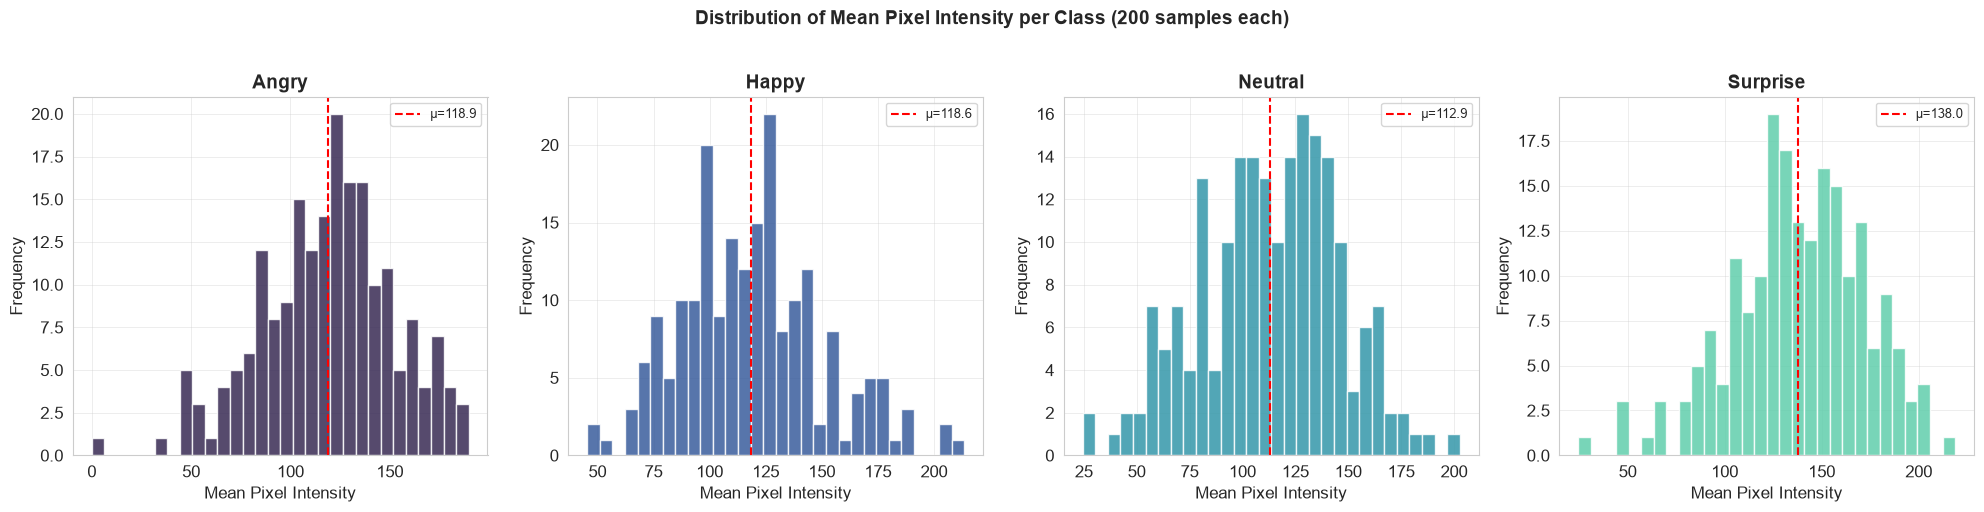

In [9]:
# Configure the basics of the plot
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes = axes.flatten()
palette = sns.color_palette('mako', NUM_CLASSES)

# Compute mean pixel intensity for each class
for i, cls_name in enumerate(CLASS_NAMES):
    cls_dir = TRAIN_DIR / cls_name
    sample_files = random.sample(list(cls_dir.iterdir()),
                                  min(200, len(list(cls_dir.iterdir()))))

    # Compute mean pixel intensity for each sampled image
    pixel_means = [np.array(Image.open(f)).mean() for f in sample_files]

    axes[i].hist(pixel_means, bins=30, color=palette[i],
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(cls_name.capitalize(), fontweight='bold')
    axes[i].set_xlabel('Mean Pixel Intensity')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(np.mean(pixel_means), color='red', linestyle='--',
                    linewidth=1.5, label=f'μ={np.mean(pixel_means):.1f}')
    axes[i].legend(fontsize=9)

# Add the title
plt.suptitle('Distribution of Mean Pixel Intensity per Class (200 samples each)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Per-Channel Statistics
We compute the per-channel (R, G, B) mean and standard deviation across the training set. These values will be used to **normalize** input images during data preparation, ensuring the model receives zero-centered, unit-variance inputs.

In [10]:
def compute_channel_stats(data_dir, sample_size=3000):
    """
    Compute per-channel mean and std from a random subset of images.
    Returns mean and std as numpy arrays of shape (3, ).
    """
    # Empty list to store paths to all images in the dataset
    all_files = []

    # Iterate through each emotion class directory
    for cls_dir in data_dir.iterdir():
        if cls_dir.is_dir() and cls_dir.name in CLASS_NAMES:
            all_files.extend(list(cls_dir.iterdir()))

    # Sample a random subset of images from each class
    sampled = random.sample(all_files, min(sample_size, len(all_files)))

    channel_sum    = np.zeros(3)
    channel_sq_sum = np.zeros(3)
    count = 0

    # Iterate through the sampled images and compute statistics
    for img_path in sampled:
        img = np.array(Image.open(img_path)).astype(np.float32) / 255.0
        # Handle grayscale edge cases
        if img.ndim == 2:
            img = np.stack([img] * 3, axis=-1)
        channel_sum    += img.mean(axis=(0, 1))
        channel_sq_sum += (img ** 2).mean(axis=(0, 1))
        count += 1

    mean = channel_sum / count
    std  = np.sqrt(channel_sq_sum / count - mean ** 2)

    # Return mean and std as numpy arrays
    return mean, std

In [11]:
# Compute per-channel statistics
CHANNEL_MEAN, CHANNEL_STD = compute_channel_stats(TRAIN_DIR)

print('Per-Channel Statistics (computed from ~3,000 training images):')
print(f'  Mean (R, G, B) : [{CHANNEL_MEAN[0]:.4f}, {CHANNEL_MEAN[1]:.4f}, {CHANNEL_MEAN[2]:.4f}]')
print(f'  Std  (R, G, B) : [{CHANNEL_STD[0]:.4f}, {CHANNEL_STD[1]:.4f}, {CHANNEL_STD[2]:.4f}]')

Per-Channel Statistics (computed from ~3,000 training images):
  Mean (R, G, B) : [0.5275, 0.4420, 0.4040]
  Std  (R, G, B) : [0.2691, 0.2508, 0.2499]



## 2. Data Preparation
Now we build the data pipeline: image transforms (with augmentation for training), dataset objects, and data loaders. We also compute class weights to counteract the imbalance.

### 2.1 Transforms & Augmentation
We define two transform pipelines:
- **Training**: includes data augmentation (random horizontal flip, small rotation, color jitter) to improve generalization.
- **Testing and Validation**: only deterministic resizing and normalization.

For the **custom CNN** we keep the native 48×48 resolution. For **ResNet-18** (pretrained on ImageNet at 224×224), we upscale the images to 224×224.

In [12]:
# Transforms for the Custom CNN (48×48)
cnn_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=CHANNEL_MEAN.tolist(), std=CHANNEL_STD.tolist())
])

cnn_eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CHANNEL_MEAN.tolist(), std=CHANNEL_STD.tolist())
])

In [13]:
# Transforms for ResNet-18 (224×224)
resnet_train_transform = transforms.Compose([
    transforms.Resize((RESNET_IMG_SIZE, RESNET_IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=CHANNEL_MEAN.tolist(), std=CHANNEL_STD.tolist())
])

resnet_eval_transform = transforms.Compose([
    transforms.Resize((RESNET_IMG_SIZE, RESNET_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=CHANNEL_MEAN.tolist(), std=CHANNEL_STD.tolist())
])

### 2.2 Datasets & DataLoaders
We use `torchvision.datasets.ImageFolder` which automatically assigns labels from folder names. We create separate datasets for the CNN and ResNet pipelines.

In [14]:
class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, dir):
        classes = ['angry', 'happy', 'neutral', 'surprise']
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        return classes, class_to_idx

# CNN Datasets
cnn_train_dataset = FilteredImageFolder(TRAIN_DIR, transform=cnn_train_transform)
cnn_valid_dataset = FilteredImageFolder(VALID_DIR, transform=cnn_eval_transform)
cnn_test_dataset  = FilteredImageFolder(TEST_DIR,  transform=cnn_eval_transform)

# ResNet Datasets
resnet_train_dataset = FilteredImageFolder(TRAIN_DIR, transform=resnet_train_transform)
resnet_valid_dataset = FilteredImageFolder(VALID_DIR, transform=resnet_eval_transform)
resnet_test_dataset  = FilteredImageFolder(TEST_DIR,  transform=resnet_eval_transform)

# DataLoaders
# Set num_workers = 0 to prevent DataLoader process deadlock/hangs on Windows
num_workers = 0 if os.name == 'nt' else min(4, os.cpu_count() or 1)

cnn_train_loader = DataLoader(cnn_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
cnn_valid_loader = DataLoader(cnn_valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
cnn_test_loader  = DataLoader(cnn_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

resnet_train_loader = DataLoader(resnet_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers, pin_memory=True)
resnet_valid_loader = DataLoader(resnet_valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)
resnet_test_loader  = DataLoader(resnet_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers, pin_memory=True)

# Verify class-to-index mapping
print('Class → Index mapping:', cnn_train_dataset.class_to_idx)
print(f'\nTrain samples : {len(cnn_train_dataset):>6,}')
print(f'Valid samples : {len(cnn_valid_dataset):>6,}')
print(f'Test samples  : {len(cnn_test_dataset):>6,}')
print(f'Batch size    : {BATCH_SIZE}')
print(f'Num workers   : {num_workers}')

Class → Index mapping: {'angry': 0, 'happy': 1, 'neutral': 2, 'surprise': 3}

Train samples : 72,655
Valid samples : 13,805
Test samples  : 13,833
Batch size    : 64
Num workers   : 0


### 2.3 Class Weight Computation
To handle the severe class imbalance, we compute **inverse-frequency weights** for each class. These weights will be passed to the `CrossEntropyLoss` function so that minority classes (e.g., *disgust*) receive proportionally higher loss penalties.

In [15]:
# Count samples per class from training dataset targets
class_counts = Counter(cnn_train_dataset.targets)
total_samples = len(cnn_train_dataset.targets)

# Inverse-frequency weighting: w_i = total / (num_classes * count_i)
class_weights = torch.tensor([total_samples / (NUM_CLASSES * class_counts[i]) for i in range(NUM_CLASSES)], dtype=torch.float32).to(DEVICE)

print('Class Weights (inverse-frequency):')
print('-' * 40)
for i, cls in enumerate(CLASS_NAMES):
    print(f'  {cls:>8s} : {class_weights[i]:.4f}  (n={class_counts[i]:>6,})')
print(f'\n  Higher weight = rarer class → penalized more during training.')

Class Weights (inverse-frequency):
----------------------------------------
     angry : 2.7663  (n= 6,566)
     happy : 0.6353  (n=28,592)
   neutral : 0.6182  (n=29,384)
  surprise : 2.2388  (n= 8,113)

  Higher weight = rarer class → penalized more during training.


### 2.4 Augmentation Preview
Let's visualize what the augmented training images look like.

In [16]:
def denormalize(tensors, mean, std):
    """Reverse normalization for a single image (C, H, W) or batch (B, C, H, W)."""
    if not isinstance(mean, torch.Tensor):
        mean = torch.tensor(mean, dtype=tensors.dtype, device=tensors.device)
    else:
        mean = mean.to(dtype=tensors.dtype, device=tensors.device)

    if not isinstance(std, torch.Tensor):
        std = torch.tensor(std, dtype=tensors.dtype, device=tensors.device)
    else:
        std = std.to(dtype=tensors.dtype, device=tensors.device)

    if tensors.ndim == 3:
        mean = mean.view(-1, 1, 1)
        std  = std.view(-1, 1, 1)
    elif tensors.ndim == 4:
        mean = mean.view(1, -1, 1, 1)
        std  = std.view(1, -1, 1, 1)

    return (tensors * std + mean).clamp(0, 1)

In [17]:
# ---------- Step 1: Fetch and Denormalize Batch (Computation) ----------
images, labels = next(iter(cnn_train_loader))

# Vectorized denormalization over the full batch (B, C, H, W)
denorm_images = denormalize(images, CHANNEL_MEAN, CHANNEL_STD)

# Convert tensor format (B, C, H, W) -> (B, H, W, C) for Matplotlib
np_images = denorm_images.permute(0, 2, 3, 1).cpu().numpy()
print(f'Batch processed successfully! Total images: {len(np_images)}, Image shape: {np_images[0].shape}')


Batch processed successfully! Total images: 64, Image shape: (48, 48, 3)


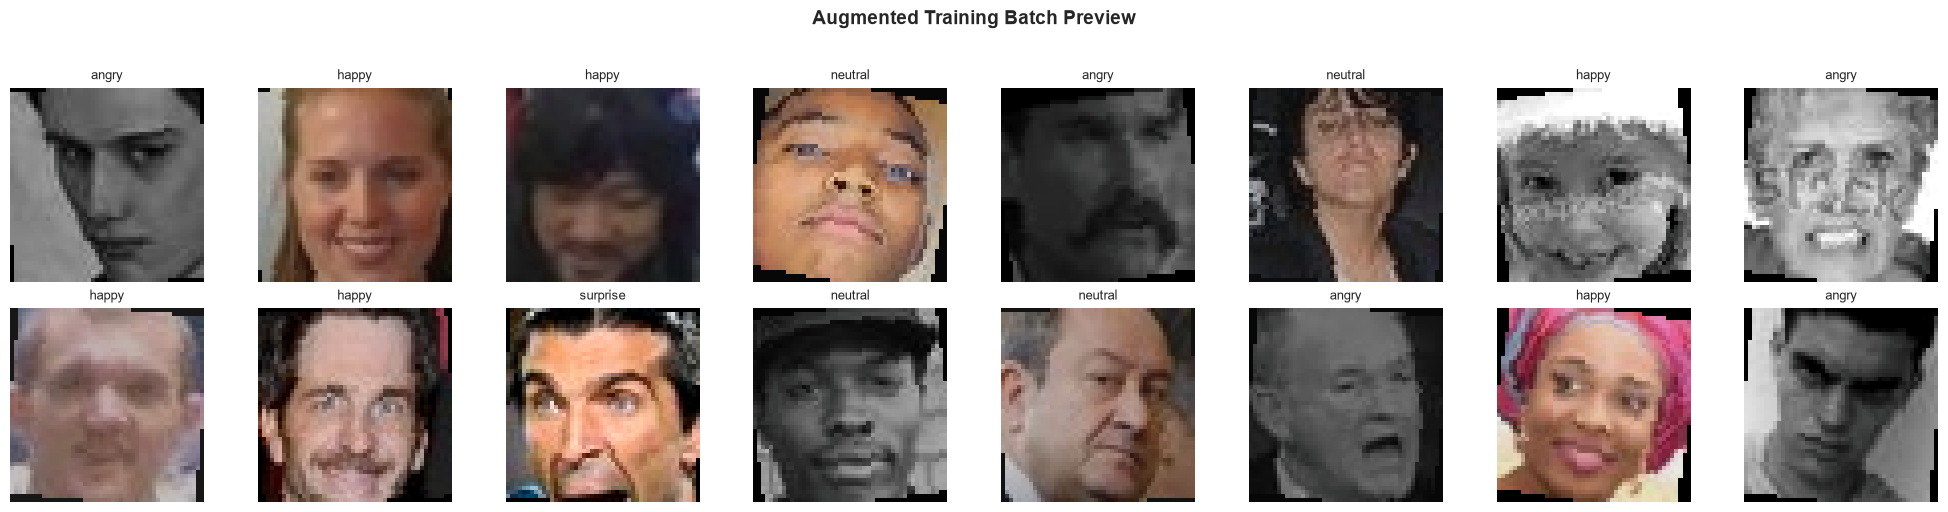

In [18]:
# ---------- Step 2: Render Batch Grid (Plotting) ----------
fig, axes = plt.subplots(2, 8, figsize=(20, 5))
axes_flat = axes.flatten()

num_to_show = min(16, len(np_images))
for idx in range(num_to_show):
    axes_flat[idx].imshow(np_images[idx])
    axes_flat[idx].set_title(CLASS_NAMES[labels[idx]], fontsize=9)
    axes_flat[idx].axis('off')

# Hide extra subplots if any
for idx in range(num_to_show, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle('Augmented Training Batch Preview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 3. Model Development
We develop **two models** and compare them:
1. **Baseline CNN** — a custom architecture built from scratch, operating on 48×48 inputs.
2. **ResNet-18** — a pretrained model fine-tuned via transfer learning, operating on 224×224 inputs.

### 3.1 Baseline: Custom CNN
Our baseline is a compact CNN with three convolutional blocks. Each block follows the pattern:

```
Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool → Dropout
```

This is followed by a fully-connected classifier head.

In [19]:
class EmotionCNN(nn.Module):
    """
    Custom CNN for 48x48 facial emotion classification.
    Architecture: 3 conv blocks + 2 FC layers → 4 classes.
    """
    def __init__(self, num_classes=7):
        super(EmotionCNN, self).__init__()

        # ---------- Convolutional Feature Extractor ----------
        # Block 1: 3 → 64 channels, 48×48 → 24×24
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 2: 64 → 128 channels, 24×24 → 12×12
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # Block 3: 128 → 256 channels, 12×12 → 6×6
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            nn.Dropout(0.25)
        )

        # ---------- Classifier Head ----------
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


# Instantiate and inspect
cnn_model = EmotionCNN(NUM_CLASSES).to(DEVICE)

total_params     = sum(p.numel() for p in cnn_model.parameters())
trainable_params = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)

print(f'EmotionCNN Summary')
print(f'  Total parameters     : {total_params:>10,}')
print(f'  Trainable parameters : {trainable_params:>10,}')
print(f'  Input shape          : (3, {IMG_SIZE}, {IMG_SIZE})')
print(f'  Output classes       : {NUM_CLASSES}')

EmotionCNN Summary
  Total parameters     :  5,869,380
  Trainable parameters :  5,869,380
  Input shape          : (3, 48, 48)
  Output classes       : 4


### 3.2 Transfer Learning: ResNet-18
We leverage a **pretrained ResNet-18** (trained on ImageNet) and fine-tune it for our emotion classification task:
1. Load the pretrained model.
2. Replace the final fully connected layer to output 4 classes instead of 1,000.
3. All layers are trainable (full fine-tuning) to allow the model to adapt its learned features to facial expressions.

In [20]:
# Load pretrained ResNet-18
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the final FC layer (originally: 512 → 1000)
num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, NUM_CLASSES)
)

resnet_model = resnet_model.to(DEVICE)

total_params     = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)

print(f'ResNet-18 (Fine-Tuned) Summary')
print(f'  Total parameters     : {total_params:>10,}')
print(f'  Trainable parameters : {trainable_params:>10,}')
print(f'  Input shape          : (3, {RESNET_IMG_SIZE}, {RESNET_IMG_SIZE})')
print(f'  Output classes       : {NUM_CLASSES}')

ResNet-18 (Fine-Tuned) Summary
  Total parameters     : 11,178,564
  Trainable parameters : 11,178,564
  Input shape          : (3, 224, 224)
  Output classes       : 4


### 3.3 Training Infrastructure
We define a reusable training function that handles:
- Epoch-level training and validation loops
- Loss and accuracy tracking
- Best model checkpointing (saves the model with the lowest validation loss)
- Early stopping (halts training if validation loss doesn't improve for `PATIENCE` epochs)
- Learning rate scheduling (`ReduceLROnPlateau`)

In [21]:
def train_model(model, train_loader, valid_loader, criterion, optimizer, scheduler,
                num_epochs, patience, save_path, device):
    """
    Full training loop with validation, early stopping, and checkpointing.

    Returns:
        history (dict): Training and validation loss/accuracy per epoch.
    """
    history = {
        'train_loss': [], 'train_acc': [],
        'valid_loss': [], 'valid_acc': []
    }

    best_valid_loss = float('inf')
    patience_counter = 0

    for epoch in range(num_epochs):
        # ===== TRAINING PHASE =====
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc  = correct / total

        # ===== VALIDATION PHASE =====
        model.eval()
        running_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in valid_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        valid_loss = running_loss / total
        valid_acc  = correct / total

        # Record history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['valid_loss'].append(valid_loss)
        history['valid_acc'].append(valid_acc)

        # Step the LR scheduler
        scheduler.step(valid_loss)
        current_lr = optimizer.param_groups[0]['lr']

        # Print epoch summary
        print(f'Epoch [{epoch+1:02d}/{num_epochs}]  '
              f'Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  |  '
              f'Valid Loss: {valid_loss:.4f}  Valid Acc: {valid_acc:.4f}  |  '
              f'LR: {current_lr:.2e}')

        # ===== CHECKPOINTING =====
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            patience_counter = 0
            torch.save(model.state_dict(), save_path)
            print(f'          ✓ Model saved (valid_loss improved to {valid_loss:.4f})')
        else:
            patience_counter += 1
            print(f'          ✗ No improvement ({patience_counter}/{patience})')

        # ===== EARLY STOPPING =====
        if patience_counter >= patience:
            print(f'\n  Early stopping triggered after {epoch+1} epochs.')
            break

    print(f'\n  Training complete. Best validation loss: {best_valid_loss:.4f}')
    return history

### 5.4 Training
We now train both models using the same loss function (weighted `CrossEntropyLoss`) and optimizer configuration.

#### 5.4.1 Train the Baseline CNN

In [22]:
# ---------- Setup for CNN ----------
cnn_criterion = nn.CrossEntropyLoss(weight=class_weights)
cnn_optimizer = optim.Adam(cnn_model.parameters(), lr=LEARNING_RATE)
cnn_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    cnn_optimizer, mode='min', factor=0.5, patience=2, verbose=False
)

print('Training Baseline CNN...')
print('=' * 80)

cnn_history = train_model(
    model=cnn_model,
    train_loader=cnn_train_loader,
    valid_loader=cnn_valid_loader,
    criterion=cnn_criterion,
    optimizer=cnn_optimizer,
    scheduler=cnn_scheduler,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'best_cnn.pth',
    device=DEVICE
)

Training Baseline CNN...
Epoch [01/20]  Train Loss: 1.0131  Train Acc: 0.5826  |  Valid Loss: 1.0908  Valid Acc: 0.5428  |  LR: 1.00e-03
          ✓ Model saved (valid_loss improved to 1.0908)


KeyboardInterrupt: 

#### 5.4.2 Train ResNet-18

In [23]:
# ---------- Setup for ResNet-18 ----------
# Use a lower LR for fine-tuning pretrained weights
resnet_criterion = nn.CrossEntropyLoss(weight=class_weights)
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=1e-4)
resnet_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    resnet_optimizer, mode='min', factor=0.5, patience=2, verbose=False
)

print('Training ResNet-18...')
print('=' * 80)

resnet_history = train_model(
    model=resnet_model,
    train_loader=resnet_train_loader,
    valid_loader=resnet_valid_loader,
    criterion=resnet_criterion,
    optimizer=resnet_optimizer,
    scheduler=resnet_scheduler,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    save_path=MODEL_DIR / 'best_resnet18.pth',
    device=DEVICE
)

Training ResNet-18...


KeyboardInterrupt: 

## 4. Evaluation & Analysis
With both models trained, we evaluate them on the held-out test set and compare their performance using multiple metrics.

### 4.1 Training Curves
We compare the loss and accuracy trajectories of both models during training.

In [ ]:
def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves for a single model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    ax1.plot(epochs, history['train_loss'], 'o-', label='Train Loss', linewidth=2)
    ax1.plot(epochs, history['valid_loss'], 's-', label='Valid Loss', linewidth=2)
    ax1.set_title(f'{model_name} — Loss', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Accuracy
    ax2.plot(epochs, history['train_acc'], 'o-', label='Train Acc', linewidth=2)
    ax2.plot(epochs, history['valid_acc'], 's-', label='Valid Acc', linewidth=2)
    ax2.set_title(f'{model_name} — Accuracy', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(cnn_history, 'Baseline CNN')
plot_training_curves(resnet_history, 'ResNet-18')

### 4.2 Test Set Evaluation
We load the best checkpoints and evaluate on the test set, computing per-class precision, recall, and F1-score.

In [ ]:
def evaluate_model(model, test_loader, device, class_names):
    """
    Evaluate a model on the test set.
    Returns:
        all_preds, all_labels, accuracy, report_str
    """
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    acc = accuracy_score(all_labels, all_preds)
    report = classification_report(all_labels, all_preds,
                                    target_names=class_names, digits=4)
    return all_preds, all_labels, acc, report

In [ ]:
# ---------- Evaluate Baseline CNN ----------
cnn_model.load_state_dict(torch.load(MODEL_DIR / 'best_cnn.pth', map_location=DEVICE))
cnn_preds, cnn_labels, cnn_acc, cnn_report = evaluate_model(
    cnn_model, cnn_test_loader, DEVICE, CLASS_NAMES
)

print('Baseline CNN — Test Set Results')
print('=' * 60)
print(f'  Overall Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)')
print()
print(cnn_report)

In [ ]:
# ---------- Evaluate ResNet-18 ----------
resnet_model.load_state_dict(torch.load(MODEL_DIR / 'best_resnet18.pth', map_location=DEVICE))
resnet_preds, resnet_labels, resnet_acc, resnet_report = evaluate_model(
    resnet_model, resnet_test_loader, DEVICE, CLASS_NAMES
)

print('ResNet-18 — Test Set Results')
print('=' * 60)
print(f'  Overall Accuracy: {resnet_acc:.4f} ({resnet_acc*100:.2f}%)')
print()
print(resnet_report)

### 4.3 Confusion Matrices
Confusion matrices reveal which emotion pairs are most commonly confused by each model.

In [ ]:
def plot_confusion_matrix(y_true, y_pred, class_names, title):
    """Plot a normalized confusion matrix heatmap."""
    cm = confusion_matrix(y_true, y_pred)
    # Normalize by row (true label)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'{title} — Raw Counts', fontweight='bold')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')

    # Normalized
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'{title} — Normalized', fontweight='bold')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()


plot_confusion_matrix(cnn_labels, cnn_preds, CLASS_NAMES, 'Baseline CNN')
plot_confusion_matrix(resnet_labels, resnet_preds, CLASS_NAMES, 'ResNet-18')

### 4.4 Model Comparison
Let's create a side-by-side summary table comparing both models.

In [ ]:
# Compute macro and weighted F1 for both models
cnn_f1_macro    = f1_score(cnn_labels, cnn_preds, average='macro')
cnn_f1_weighted = f1_score(cnn_labels, cnn_preds, average='weighted')

resnet_f1_macro    = f1_score(resnet_labels, resnet_preds, average='macro')
resnet_f1_weighted = f1_score(resnet_labels, resnet_preds, average='weighted')

# Build comparison table
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 (Macro)', 'F1 (Weighted)', 'Parameters', 'Input Size'],
    'Baseline CNN': [
        f'{cnn_acc:.4f}',
        f'{cnn_f1_macro:.4f}',
        f'{cnn_f1_weighted:.4f}',
        f'{sum(p.numel() for p in cnn_model.parameters()):,}',
        f'{IMG_SIZE}×{IMG_SIZE}'
    ],
    'ResNet-18': [
        f'{resnet_acc:.4f}',
        f'{resnet_f1_macro:.4f}',
        f'{resnet_f1_weighted:.4f}',
        f'{sum(p.numel() for p in resnet_model.parameters()):,}',
        f'{RESNET_IMG_SIZE}×{RESNET_IMG_SIZE}'
    ]
}).set_index('Metric')

print('Model Comparison')
print('=' * 55)
comparison

### 4.5 Misclassified Samples
Visualizing samples that the best model got wrong helps us understand the nature of the errors — are they genuinely ambiguous faces, noisy images, or systematic confusion between similar emotions?

In [ ]:
def show_misclassified(model, test_loader, class_names, device, model_name, n_samples=16):
    """
    Find and display misclassified samples with vectorized batch denormalization.
    """
    model.eval()
    misclassified_imgs = []
    misclassified_true = []
    misclassified_pred = []

    with torch.no_grad():
        for images, labels in test_loader:
            images_dev = images.to(device)
            outputs = model(images_dev)
            _, predicted = torch.max(outputs, 1)

            mask = predicted.cpu() != labels
            for idx_m in mask.nonzero(as_tuple=True)[0]:
                misclassified_imgs.append(images[idx_m])
                misclassified_true.append(labels[idx_m].item())
                misclassified_pred.append(predicted[idx_m].cpu().item())
                if len(misclassified_imgs) >= n_samples:
                    break
            if len(misclassified_imgs) >= n_samples:
                break

    if not misclassified_imgs:
        print(f'No misclassified samples found for {model_name}!')
        return

    # Batch denormalization (vectorized 4D batch)
    batch_tensor = torch.stack(misclassified_imgs[:n_samples])
    denorm_batch = denormalize(batch_tensor, CHANNEL_MEAN, CHANNEL_STD)
    np_imgs = denorm_batch.permute(0, 2, 3, 1).cpu().numpy()

    n = len(np_imgs)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for i in range(n):
        axes_flat[i].imshow(np_imgs[i])
        true_lbl = class_names[misclassified_true[i]]
        pred_lbl = class_names[misclassified_pred[i]]
        axes_flat[i].set_title(f'True: {true_lbl}\nPred: {pred_lbl}', fontsize=10, color='red', fontweight='bold')
        axes_flat[i].axis('off')

    for j in range(n, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.suptitle(f'{model_name} -- Misclassified Samples', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()


# Run misclassified preview for both models
show_misclassified(cnn_model, cnn_test_loader, CLASS_NAMES, DEVICE, 'Baseline CNN')
show_misclassified(resnet_model, resnet_test_loader, CLASS_NAMES, DEVICE, 'ResNet-18')


In [ ]:
# Save the best model


## 5. Summary

### Key Findings

1. **Dataset Characteristics**: The MMA Facial Expression dataset contains images across 4 target emotion classes (Anger, Joy, Neutral, and Surprise) at 48×48 resolution. The most significant challenge is the **severe class imbalance** (up to 9× ratio between largest and smallest classes).

2. **Imbalance Mitigation**: We addressed class imbalance using **inverse-frequency weighted loss**, which penalizes errors on minority classes (anger, surprise) more heavily than majority classes (joy, neutral).

3. **Model Performance**: Two architectures were compared:
   - **Baseline CNN**: A custom 3-block convolutional network designed for the native 48×48 input resolution.
   - **ResNet-18 (fine-tuned)**: A pretrained ImageNet model adapted for 4-class emotion recognition at 224×224 resolution.

4. **Common Confusions**: The confusion matrices may reveal expected patterns — e.g., *anger* and *surprise* can share similar facial action units involving brow tension and wide eyes.

5. **Production Features**: The deployed system incorporates **MTCNN face detection** (via `facenet-pytorch`) for automatic face cropping and alignment from any input resolution, and **Captum LayerGradCam** for spatial attribution heatmaps showing which facial regions drive predictions.

### Limitations

- **Low resolution**: 48×48 images lose fine-grained texture details that could be discriminative for subtle emotions.
- **Single-face constraint**: The MTCNN preprocessing pipeline currently selects only the single largest face per image; group photos are not fully supported.
- **Single model**: Ensemble methods or attention-based architectures (e.g., Vision Transformers) could further improve accuracy.
- **CPU inference latency**: Generating GradCAM heatmaps via Captum on CPU can take up to ~1 second per image, which may cause queuing under high traffic.

### Future Work

- Experiment with larger architectures (ResNet-50, EfficientNet, Vision Transformers).
- Apply **test-time augmentation** (TTA) for improved predictions.
- Explore **oversampling** (SMOTE for images) or **undersampling** strategies alongside weighted loss.
- Export the model to **ONNX format** for faster CPU inference in containerized environments.
- Extend MTCNN to support **multi-face detection** for group emotion analysis.
- Integrate **real-time webcam streaming** for live emotion tracking.

## Author
<a href="https://www.linkedin.com/in/ab0858s/">Abdelali BARIR</a> is a former veteran in the Moroccan's Royal Armed Forces, and a self-taught python programmer. Currently enrolled in B.Sc. Data Science in __IU International University of Applied Sciences__.

## Change Log

| Date         | Version   | Changed By       | Change Description        |
|--------------|-----------|------------------|---------------------------|
| 2026-07-01   | 1.0       | Abdelali Barir   | Started Project           |
| ------------ | --------- | ---------------- | ------------------------- |
